### The transient Universe pt 2


Let's go back to our previous example on the astrophysical transient.


8) Fit the same model from before with the same priors,  but this time use nested sampling.

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors (I used `ppf` from `scipy.stats.uniform`, but there are other ways to do it)

An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.

7) Another possible model that may explain the data is a Gaussian profile described by:

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

Fit this model usign nested sampling and reasonable priors (this time is up to you to decide...)

9) Unlike MCMCs, nested sampling provides the Bayesian evidence. Compute the Bayesian evidence for this Gaussian model, and for the original burst model. Which model is the favored description of the data? Express this in terms of the Jeffrey's scale.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats 
import emcee
import corner
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
import warnings
warnings.filterwarnings("ignore")

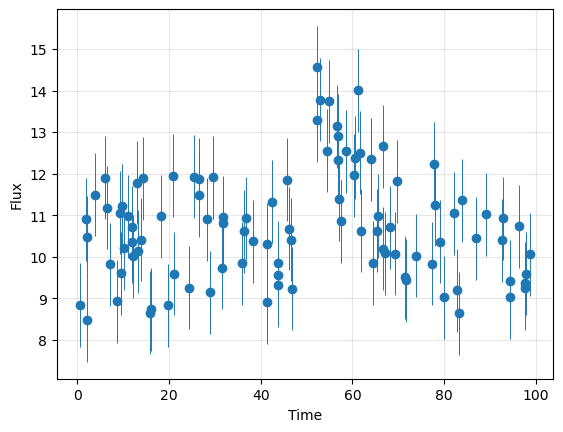

In [14]:
data = np.load("transient.npy")
time = data[:, 0]
flux = data[:, 1]
err = data[:, 2]

plt.errorbar(time, flux, yerr=err, fmt='o', elinewidth=0.7)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.grid(alpha=0.3)

Let's fit the burst model using Nested Sampling:

In [15]:
def burst_model(theta, time):
    A, b, alpha, t0 = theta
    y = np.zeros_like(time)
    for i in range(len(time)):
        if time[i] < t0:
            y[i] = b
        else:
            y[i] = b + A * np.exp(-alpha * (time[i] - t0))
    return y

In [16]:
def loglikelihood(theta, flux, time, err):
    return -0.5 * np.sum((flux-burst_model(theta, time))**2 / err**2) 

def prior_transform(u):
    A = stats.uniform.ppf(u[0], 0, 50)  # Percent point function (inverse of cdf)
    b = stats.uniform.ppf(u[1], 0, 50)
    log_alpha = stats.uniform.ppf(u[3], -5, 5)
    alpha  = np.exp(log_alpha)
    t0 = stats.uniform.ppf(u[2], 0, 100)
    return np.array([A, b, alpha, t0])

In [17]:
ndim = 4
sampler = dynesty.NestedSampler(loglikelihood, prior_transform, ndim, logl_args=(flux, time, err), nlive=300)
sampler.run_nested()
res = sampler.results

4549it [01:07, 67.89it/s, +300 | bound: 137 | nc: 1 | ncall: 72812 | eff(%):  6.687 | loglstar:   -inf < -48.755 <    inf | logz: -62.634 +/-  0.208 | dlogz:  0.001 >  0.309]


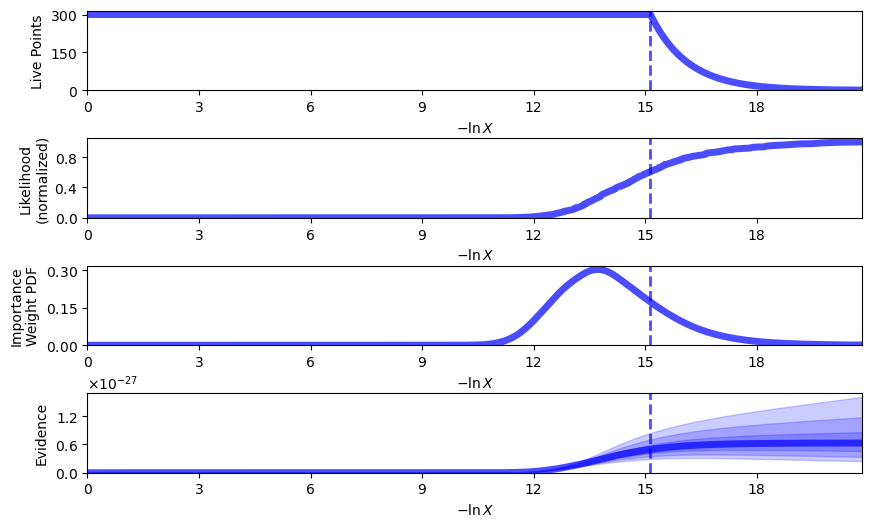

In [18]:
rfig, raxes = dyplot.runplot(res)
rfig.set_size_inches(10, 6)
rfig.subplots_adjust(hspace=0.6) # just so they don't overlap

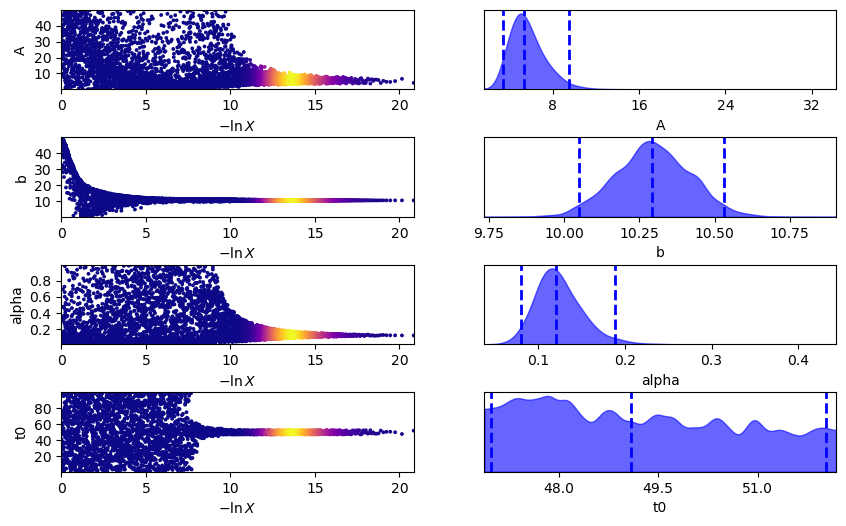

In [20]:
labels = ['A', 'b', 'alpha', 't0']
cfig, taxes = dyplot.traceplot(res, labels=labels)
cfig.set_size_inches(10, 6)
cfig.subplots_adjust(hspace=0.6) # just so they don't overlap

If everything is correct, our corner plot of the parameters should be similar to the one we obtained with MCMC previously:

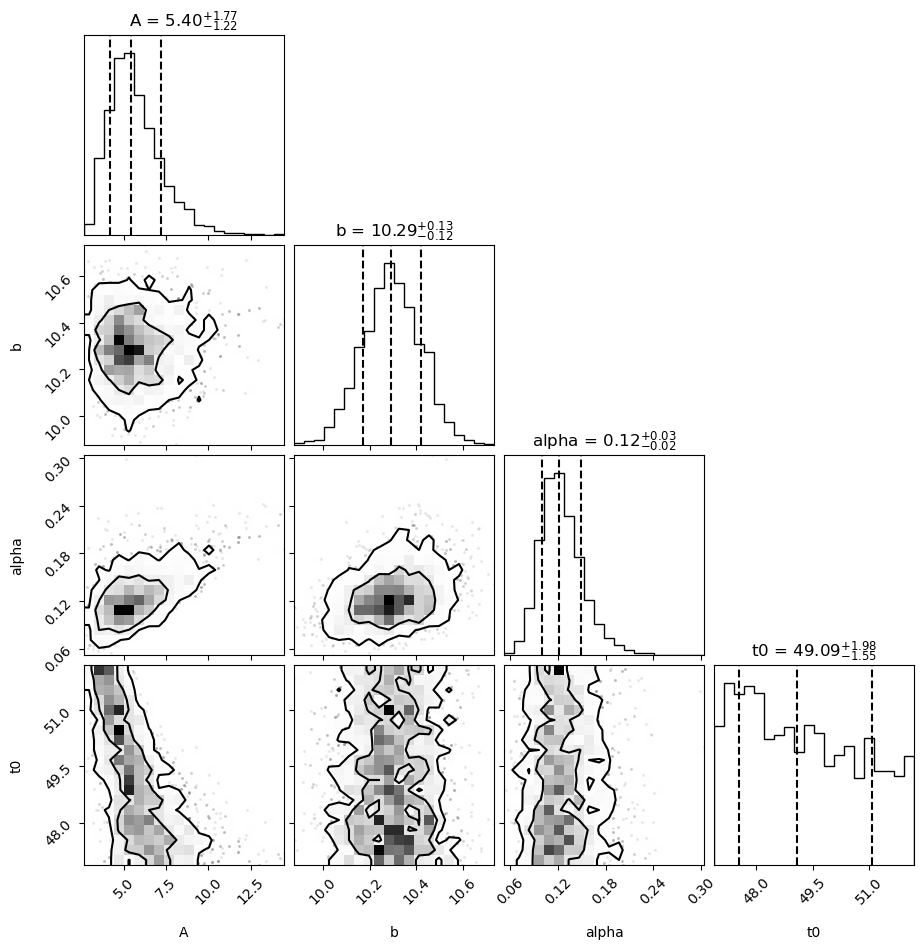

In [21]:
samples = res.samples
weights = np.exp(res.logwt - res.logz[-1])
burst_evidence = np.exp(res.logz[-1])

samples_new = dyfunc.resample_equal(samples, weights)

fig = corner.corner(samples_new, labels=labels, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()

In [22]:
med_burst = []
for i in range(4):
    low, median, up = np.quantile(samples_new[:,i], [0.05, 0.5, 0.95])
    print(f'{labels[i]} = {median} + {up-median} - {median-low}')
    med_burst.append(median)

A = 5.397716664980763 + 3.2938488869380826 - 1.757412113189122
b = 10.292995460101185 + 0.20110639464924773 - 0.2038411892524934
alpha = 0.12084650506368781 + 0.05178612380376042 - 0.034795111843327384
t0 = 49.088723415017945 + 2.7759959161848684 - 1.9953272688018089


They look very similar!

Let's now try to fit our data this time with a Gaussian model:

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

In [23]:
def gauss_model(theta, time):
    A, b, sigma, t0 = theta
    y = b + A * np.exp(-0.5 * ((time - t0) / sigma)**2)
    return y

In [24]:
def loglikelihood(theta, flux, time, err):
    return -0.5 * np.sum((flux-gauss_model(theta, time))**2 / err**2) 

def prior_transform(u):
    A  = stats.uniform.ppf(u[0], 0, 50)
    b  = stats.uniform.ppf(u[1], 0, 50)
    sigma = stats.loguniform.ppf(u[2], np.exp(-2), np.exp(2)) 
    t0 = stats.uniform.ppf(u[3], 0, 100)
    return np.array([A, b, sigma, t0])

In [25]:
ndim = 4
sampler = dynesty.NestedSampler(loglikelihood, prior_transform, ndim, logl_args=(flux, time, err), nlive=300)
sampler.run_nested()
res = sampler.results

4913it [01:40, 48.83it/s, +300 | bound: 220 | nc: 1 | ncall: 109775 | eff(%):  4.762 | loglstar:   -inf < -52.492 <    inf | logz: -67.615 +/-  0.218 | dlogz:  0.001 >  0.309]


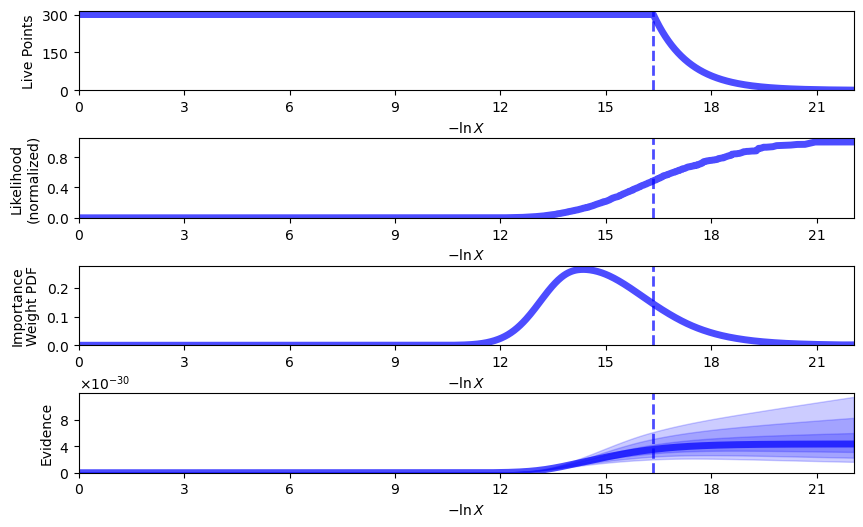

In [26]:
rfig, raxes = dyplot.runplot(res)
rfig.set_size_inches(10, 6)
rfig.subplots_adjust(hspace=0.6) # just so they don't overlap

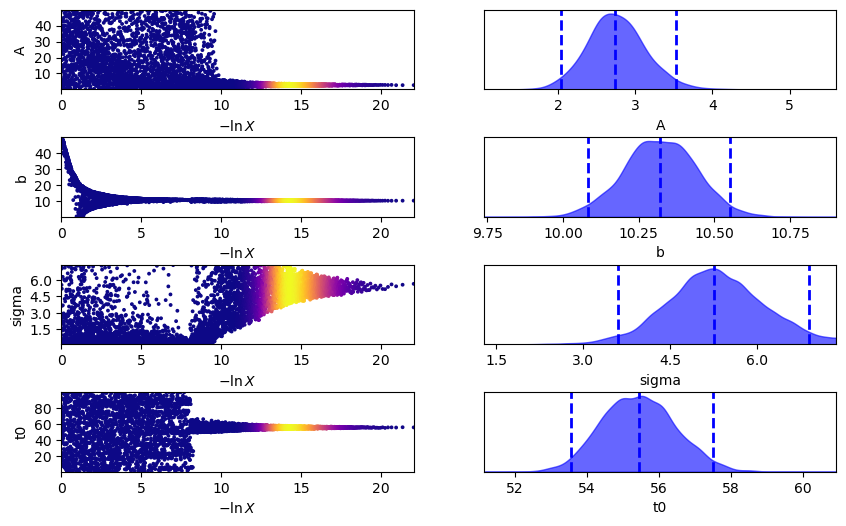

In [27]:
labels_gauss = ['A', 'b', 'sigma', 't0']

cfig, taxes = dyplot.traceplot(res, labels=labels_gauss)
cfig.set_size_inches(10, 6)
cfig.subplots_adjust(hspace=0.6) # just so they don't overlap

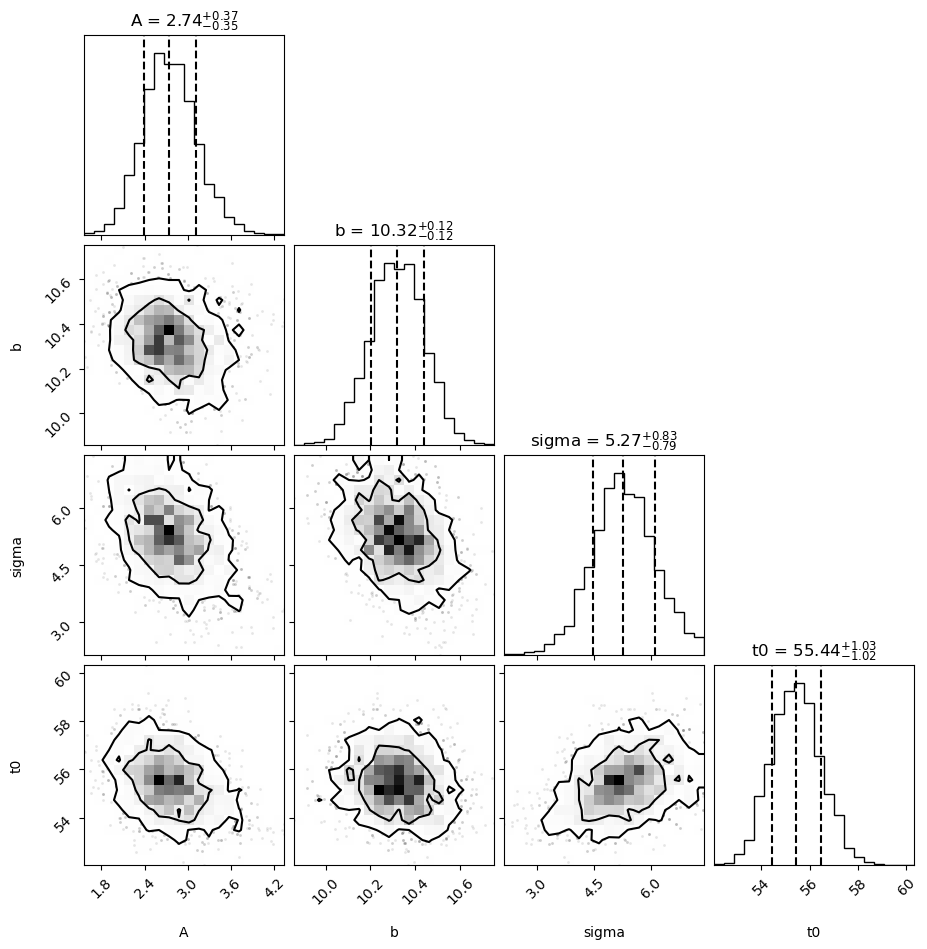

In [28]:
samples = res.samples
weights = np.exp(res.logwt - res.logz[-1])
gauss_evidence = np.exp(res.logz[-1])

samples_new = dyfunc.resample_equal(samples, weights)

fig = corner.corner(samples_new, labels=labels_gauss, levels=[0.68,0.95], quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()

The ratio between the evidence of each model is:

In [29]:
B = burst_evidence / gauss_evidence
print(f"Burst vs Gaussian model Bayes factor: {B:.2f}")

Burst vs Gaussian model Bayes factor: 145.54


So the preferred model is the Burst model!

In [30]:
med_gauss = []
for i in range(4):
    low, median, up = np.quantile(samples_new[:,i], [0.05, 0.5, 0.95])
    print(f'{labels[i]} = {median} + {up-median} - {median-low}')
    med_gauss.append(median)

A = 2.7425114615191424 + 0.6576487979205181 - 0.5886083069958854
b = 10.319007783115596 + 0.1944344689429176 - 0.19771966951592113
alpha = 5.266070186857589 + 1.399465716315163 - 1.3004917870973522
t0 = 55.43967255225972 + 1.7200065325131817 - 1.6102897471950257


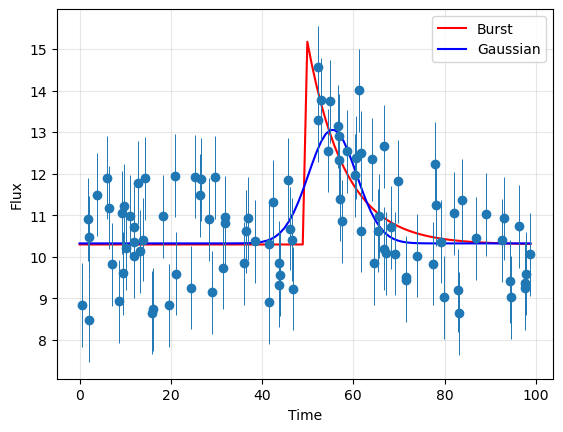

In [32]:
x_grid = np.linspace(0, np.max(time), len(time))
plt.plot(x_grid, burst_model(med_burst, x_grid), color='red', label='Burst')
plt.plot(x_grid, gauss_model(med_gauss, x_grid), color='blue', label='Gaussian')
plt.legend()
plt.errorbar(time, flux, yerr=err, fmt='o', elinewidth=0.7)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.grid(alpha=0.3)